<a href="https://colab.research.google.com/github/YuriFla94/Procesin/blob/main/tarefa4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparação entre DTFT e DFT

Este notebook compara a DTFT contínua com a DFT amostrada para o sinal:
$x[n] = \delta[n] - \delta[n-1] + \delta[n-2] - \delta[n-3]$

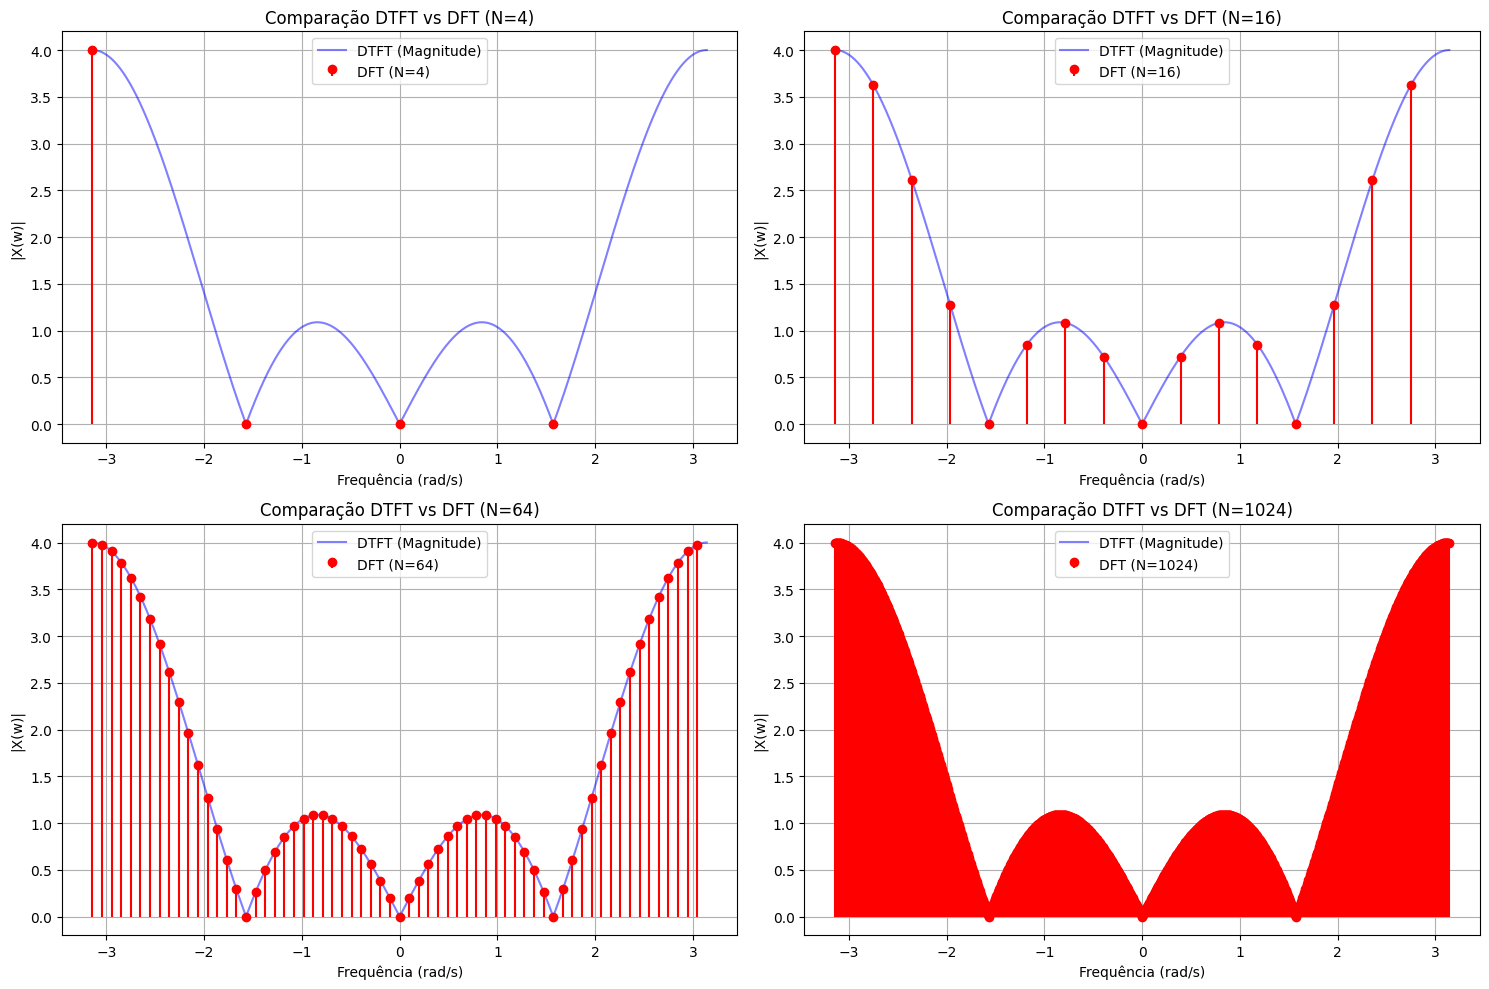

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_dtft(x, w):
    """Calcula a DTFT para um sinal x em frequências w."""
    n = np.arange(len(x))
    # DTFT: X(e^{jw}) = sum(x[n] * e^{-jwn})
    return np.array([np.sum(x * np.exp(-1j * ww * n)) for ww in w])

# Definição do sinal x[n]
x = np.array([1, -1, 1, -1])

# Frequências para a DTFT (contínua)
w_cont = np.linspace(-np.pi, np.pi, 1000)
X_dtft = calculate_dtft(x, w_cont)

# Valores de N para a DFT
Ns = [4, 16, 64, 1024]

plt.figure(figsize=(15, 10))

for i, N in enumerate(Ns):
    plt.subplot(2, 2, i+1)

    # Calcula a DFT usando FFT (com zero-padding para N > 4)
    X_dft = np.fft.fft(x, n=N)
    # Shift para centralizar em zero
    X_dft_shifted = np.fft.fftshift(X_dft)
    w_dft = np.linspace(-np.pi, np.pi, N, endpoint=False)

    # Plotagem
    plt.plot(w_cont, np.abs(X_dtft), label='DTFT (Magnitude)', color='blue', alpha=0.5)
    plt.stem(w_dft, np.abs(X_dft_shifted), linefmt='red', markerfmt='ro', basefmt=' ', label=f'DFT (N={N})')

    plt.title(f'Comparação DTFT vs DFT (N={N})')
    plt.xlabel('Frequência (rad/s)')
    plt.ylabel('|X(w)|')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

### Comentários sobre os resultados:

1.  **N=4**: Como o sinal original tem comprimento 4, a DFT com $N=4$ fornece exatamente os componentes de frequência fundamentais sem interpolação. Note que os pontos da DFT tocam exatamente a curva da DTFT.
2.  **Amostragem**: A DFT é essencialmente uma versão amostrada da DTFT. A relação é $\omega_k = \frac{2\pi k}{N}$.
3.  **Resolução Espectral**: À medida que $N$ aumenta ($16, 64, 1024$), o número de amostras na frequência aumenta. Isso não altera a resolução física (a capacidade de distinguir dois tons próximos), mas melhora a resolução visual, preenchendo o formato da DTFT (isso é o efeito do *zero-padding* no domínio do tempo).
4.  **Envelopamento**: Para $N=1024$, a DFT é virtualmente indistinguível da DTFT contínua, demonstrando como a computação digital (discreta) aproxima o domínio analógico (contínuo).

# Análise de Resolução Espectral: DFT e Zero-Padding

Nesta seção, avaliamos o sinal $x(t) = \sin(2\pi t) + \sin(2,2\pi t)$ com $f_s = 10$ Hz.
As frequências presentes são $f_1 = 1.0$ Hz e $f_2 = 1.1$ Hz.

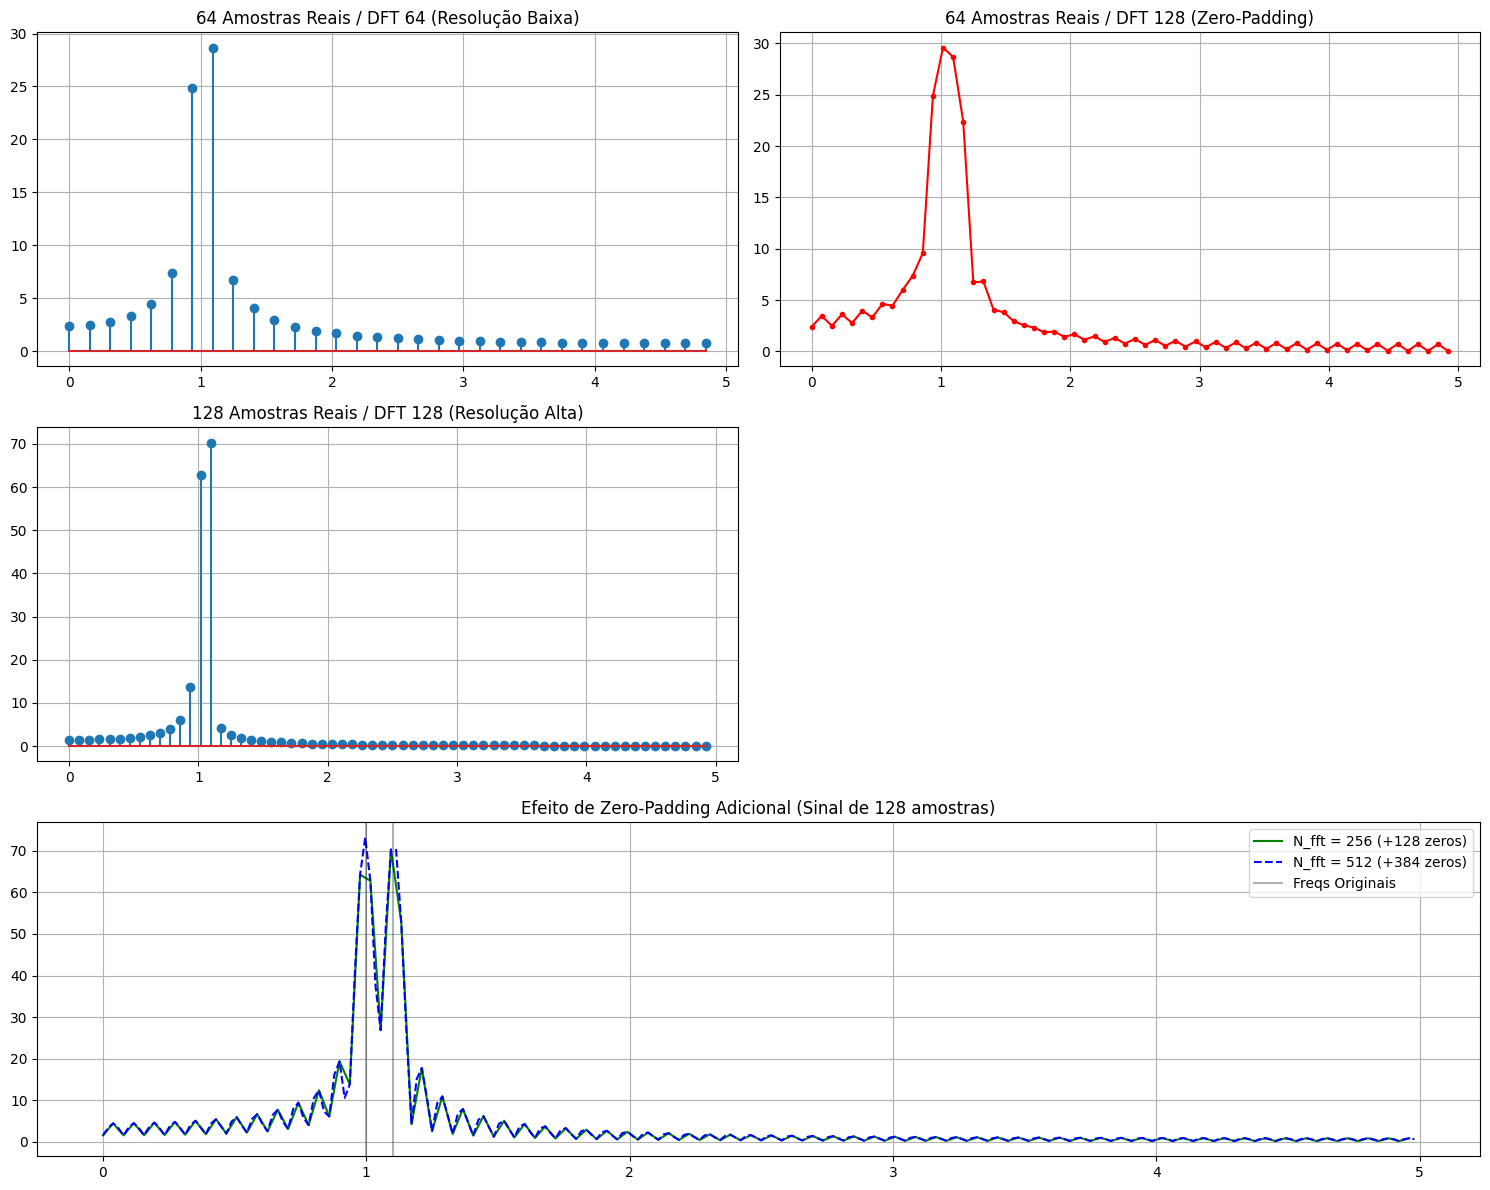

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fs = 10.0
f1, f2 = 1.0, 1.1

def get_spectrum(n_samples, n_fft):
    t = np.arange(n_samples) / fs
    x = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)
    X = np.fft.fft(x, n=n_fft)
    freqs = np.fft.fftfreq(n_fft, d=1/fs)
    # Retornar apenas a metade positiva do espectro para visualização
    half = n_fft // 2
    return freqs[:half], np.abs(X[:half])

# Cenários solicitados
plt.figure(figsize=(15, 12))

# 1. 64 amostras, DFT 64
f, mag = get_spectrum(64, 64)
plt.subplot(3, 2, 1)
plt.stem(f, mag)
plt.title("64 Amostras Reais / DFT 64 (Resolução Baixa)")
plt.grid(True)

# 2. 64 amostras, DFT 128 (64 zeros)
f, mag = get_spectrum(64, 128)
plt.subplot(3, 2, 2)
plt.plot(f, mag, 'r.-')
plt.title("64 Amostras Reais / DFT 128 (Zero-Padding)")
plt.grid(True)

# 3. 128 amostras, DFT 128 (Sem zero-padding)
f, mag = get_spectrum(128, 128)
plt.subplot(3, 2, 3)
plt.stem(f, mag)
plt.title("128 Amostras Reais / DFT 128 (Resolução Alta)")
plt.grid(True)

# 4. 128 amostras + Zero Padding (128 e 384 zeros)
f128, mag128 = get_spectrum(128, 256) # +128 zeros
f512, mag512 = get_spectrum(128, 512) # +384 zeros

plt.subplot(3, 1, 3)
plt.plot(f128, mag128, 'g-', label='N_fft = 256 (+128 zeros)')
plt.plot(f512, mag512, 'b--', label='N_fft = 512 (+384 zeros)')
plt.axvline(f1, color='k', alpha=0.3, label='Freqs Originais')
plt.axvline(f2, color='k', alpha=0.3)
plt.title("Efeito de Zero-Padding Adicional (Sinal de 128 amostras)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Discussão dos Resultados

1. **Resolução Espectral**: Definida como $\Delta f = f_s / N_{sinal}$. Para 64 amostras, $\Delta f = 10/64 \approx 0.156$ Hz. Como a distância entre as frequências ($0.1$ Hz) é menor que a resolução, elas se fundem em um único lobo.
2. **Zero-Padding**: Ao adicionar zeros (64 para 128), o espectro parece mais "suave" porque estamos interpolando a DTFT (amostrando em mais pontos), mas a capacidade de distinguir os dois picos **não melhora**. O alargamento do lobo principal (função sinc) é determinado apenas pelo tempo de observação real.
3. **Aumento de Amostras Reais**: Com 128 amostras, $\Delta f = 10/128 \approx 0.078$ Hz. Como agora a resolução é menor que a separação das frequências ($0.078 < 0.1$), os dois picos tornam-se visíveis.
4. **Limitação**: O zero-padding melhora a *resolução visual* (interpolação), mas apenas o aumento do número de amostras reais (tempo total) melhora a *resolução física* do sinal.

# Compressão de Áudio: DFT vs DCT

Nesta seção, comparamos a eficiência da Transformada Discreta de Fourier (DFT) e da Transformada de Cosseno Discreta (DCT) para compressão do sinal `handel.wav`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct, idct
from IPython.display import Audio

# Carregar o arquivo de áudio
fs, data = wavfile.read('/content/handel.wav')
# Normalizar e garantir que é mono
if len(data.shape) > 1:
    data = data[:, 0]
data = data.astype(float) / np.max(np.abs(data))

def compress_signal(signal, method='dft', ratio=0.995):
    if method == 'dft':
        coeffs = np.fft.fft(signal)
    else:
        coeffs = dct(signal, norm='ortho')

    # Calcular energia e ordenar coeficientes por magnitude
    mag_sq = np.abs(coeffs)**2
    idx = np.argsort(mag_sq)[::-1]

    total_energy = np.sum(mag_sq)
    cumulative_energy = np.cumsum(mag_sq[idx]) / total_energy

    # Encontrar quantos coeficientes são necessários para atingir o ratio r
    k = np.searchsorted(cumulative_energy, ratio) + 1

    # Zerar coeficientes menos significativos
    compressed_coeffs = np.zeros_like(coeffs)
    compressed_coeffs[idx[:k]] = coeffs[idx[:k]]

    if method == 'dft':
        reconstructed = np.fft.ifft(compressed_coeffs).real
    else:
        reconstructed = idct(compressed_coeffs, norm='ortho')

    mse = np.mean((signal - reconstructed)**2)
    return reconstructed, k, mse

ratios = [0.995, 0.99, 0.9, 0.75, 0.5]
results = {'dft': [], 'dct': []}

for r in ratios:
    for method in ['dft', 'dct']:
        rec, k, mse = compress_signal(data, method, r)
        results[method].append((r, k, mse, rec))

# Tabela de resultados
print(f"{'Ratio':<10} | {'Method':<6} | {'Coeffs':<10} | {'MSE':<12}")
print("-" * 45)
for i in range(len(ratios)):
    r_val = ratios[i]
    dft_res = results['dft'][i]
    dct_res = results['dct'][i]
    print(f"{r_val*100:>8.1f}% | {'DFT':<6} | {dft_res[1]:<10} | {dft_res[2]:.2e}")
    print(f"{r_val*100:>8.1f}% | {'DCT':<6} | {dct_res[1]:<10} | {dct_res[2]:.2e}")

Ratio      | Method | Coeffs     | MSE         
---------------------------------------------
    99.5% | DFT    | 48670      | 3.01e-04
    99.5% | DCT    | 40702      | 3.01e-04
    99.0% | DFT    | 40986      | 6.02e-04
    99.0% | DCT    | 33683      | 6.02e-04
    90.0% | DFT    | 11661      | 6.02e-03
    90.0% | DCT    | 9038       | 6.02e-03
    75.0% | DFT    | 4325       | 1.50e-02
    75.0% | DCT    | 3200       | 1.50e-02
    50.0% | DFT    | 1170       | 3.01e-02
    50.0% | DCT    | 835        | 3.01e-02


### Comparação Auditiva (Exemplo para r=90%)

Abaixo você pode ouvir o original e as versões comprimidas com 90% da energia.

In [ ]:
print("Original:")
display(Audio(data, rate=fs))

# Resultados para r=0.9 (índice 2 na lista)
print("DFT (90% energia):")
display(Audio(results['dft'][2][3], rate=fs))

print("DCT (90% energia):")
display(Audio(results['dct'][2][3], rate=fs))

Original:


DFT (90% energia):


DCT (90% energia):


# Análise de Energia de Imagem 2D com DCT

Nesta seção, aplicamos a DCT bidimensional na imagem `sosias.jpg` para observar a compactação de energia no domínio da frequência.

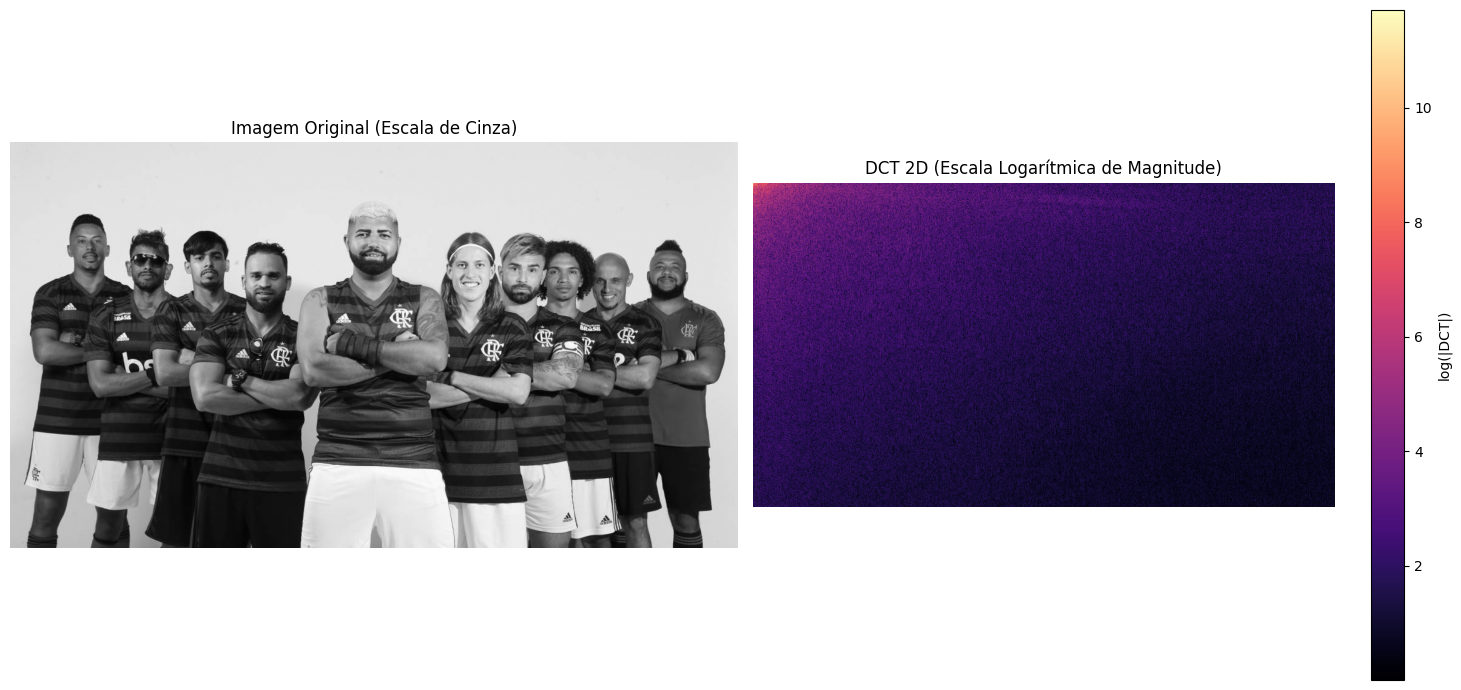

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from PIL import Image

# Carregar a imagem e converter para escala de cinza
img = Image.open('/content/sosias.jpg').convert('L')
img_data = np.array(img).astype(float)

def dct2(a):
    # DCT bidimensional
    return dct(dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    # IDCT bidimensional
    return idct(idct(a.T, norm='ortho').T, norm='ortho')

# Calcular a DCT 2D
img_dct = dct2(img_data)

# Visualização
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_data, cmap='gray')
plt.title('Imagem Original (Escala de Cinza)')
plt.axis('off')

plt.subplot(1, 2, 2)
# Usamos log na escala para visualizar melhor os coeficientes,
# já que a energia é muito concentrada em poucos pontos
plt.imshow(np.log(np.abs(img_dct) + 1), cmap='magma')
plt.title('DCT 2D (Escala Logarítmica de Magnitude)')
plt.colorbar(label='log(|DCT|)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Discussão dos Resultados (Análise 2D):

1. **Concentração de Energia**: Observe que o mapa de calor da DCT mostra um brilho intenso no canto superior esquerdo (coordenadas de baixa frequência). Isso indica que a grande maioria da energia da imagem está concentrada em poucos coeficientes.
2. **Frequências Espaciais**: O eixo horizontal representa frequências horizontais crescentes e o vertical frequências verticais. A maior parte do conteúdo visual de uma imagem natural como `sosias.jpg` é composta por variações suaves (baixa frequência).
3. **Potencial de Compressão**: Devido a essa compactação, poderíamos zerar a grande maioria dos coeficientes escuros (alta frequência) e ainda assim reconstruir uma imagem visualmente aceitável, que é o princípio básico do algoritmo JPEG.

# Compressão de Imagem por Blocos (Estilo JPEG)

Nesta seção, comparamos a compressão DCT aplicada em blocos de $8 \times 8$ e $64 \times 64$ para diferentes taxas de retenção de energia.

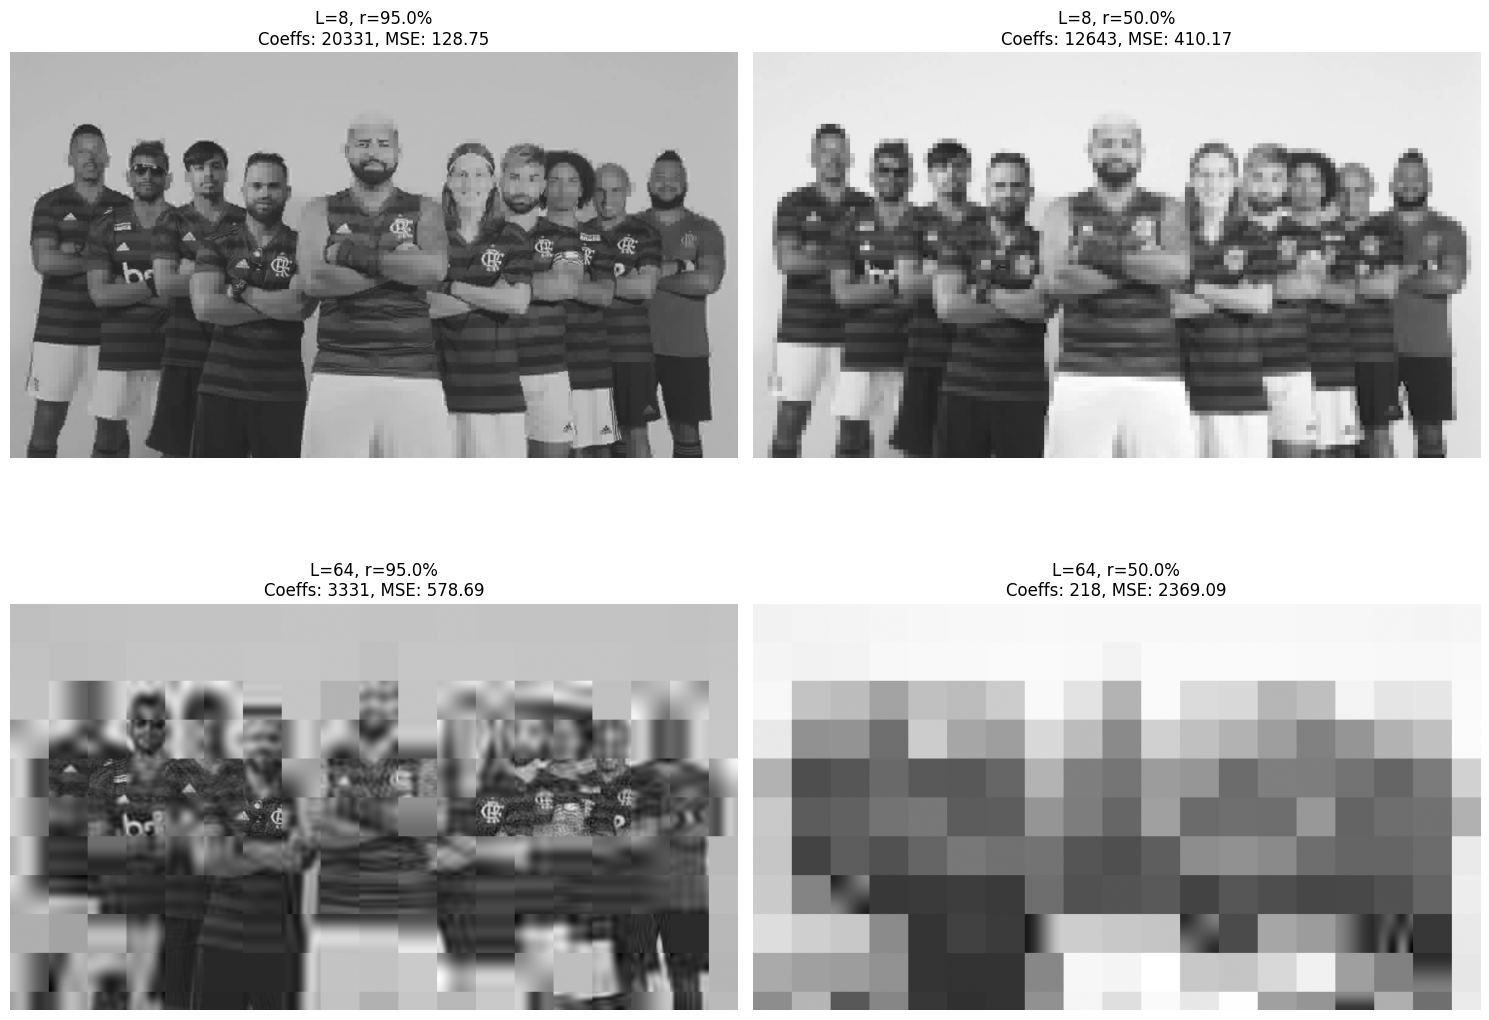

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import dct, idct
from PIL import Image

def compress_block(block, ratio):
    # DCT 2D no bloco
    coeffs = dct(dct(block.T, norm='ortho').T, norm='ortho')
    # Ordenar por magnitude
    flat_coeffs = coeffs.flatten()
    idx = np.argsort(np.abs(flat_coeffs))[::-1]

    # Calcular energia acumulada
    mag_sq = flat_coeffs**2
    total_energy = np.sum(mag_sq)
    if total_energy == 0: return np.zeros_like(block), 0

    cumulative_energy = np.cumsum(mag_sq[idx]) / total_energy
    k = np.searchsorted(cumulative_energy, ratio) + 1

    # Preservar k coeficientes
    compressed_flat = np.zeros_like(flat_coeffs)
    compressed_flat[idx[:k]] = flat_coeffs[idx[:k]]

    # IDCT 2D
    comp_coeffs = compressed_flat.reshape(block.shape)
    recon_block = idct(idct(comp_coeffs.T, norm='ortho').T, norm='ortho')
    return recon_block, k

def compress_image_blocks(img_array, L, ratio):
    h, w = img_array.shape
    recon_img = np.zeros_like(img_array)
    total_coeffs = 0

    for i in range(0, h, L):
        for j in range(0, w, L):
            block = img_array[i:i+L, j:j+L]
            # Tratar blocos nas bordas que podem ser menores que LxL
            r, c = block.shape
            recon_block, k = compress_block(block, ratio)
            recon_img[i:i+r, j:j+c] = recon_block
            total_coeffs += k

    mse = np.mean((img_array - recon_img)**2)
    return recon_img, total_coeffs, mse

# Carregar imagem
img = Image.open('/content/sosias.jpg').convert('L')
img_data = np.array(img).astype(float)

L_values = [8, 64]
ratios = [0.95, 0.50]
results_2d = []

for L in L_values:
    for r in ratios:
        recon, k, mse = compress_image_blocks(img_data, L, r)
        results_2d.append({'L': L, 'r': r, 'img': recon, 'k': k, 'mse': mse})

# Visualização dos resultados
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for i, res in enumerate(results_2d):
    axes[i].imshow(res['img'], cmap='gray')
    axes[i].set_title(f"L={res['L']}, r={res['r']*100}%\nCoeffs: {res['k']}, MSE: {res['mse']:.2f}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Discussão dos Resultados (Compressão por Blocos)

1. **Efeito de L (Tamanho do Bloco)**:
   - Com **L=8** (padrão JPEG), os erros de reconstrução são espalhados em pequenos quadrados. Em taxas de compressão agressivas ($r=50\%$), notamos o "efeito de blocagem".
   - Com **L=64**, os blocos são maiores. Embora consiga capturar tendências de baixa frequência em áreas maiores, o erro de quantização pode gerar artefatos mais visíveis e complexos dentro do bloco.

2. **Taxa de Energia (r)**:
   - Com **r=95%**, a imagem é visualmente muito próxima da original, com um MSE baixo, utilizando uma fração dos coeficientes originais.
   - Com **r=50%**, a degradação é severa. A imagem retém apenas as formas globais, perdendo texturas e detalhes finos.

3. **Eficiência**: Observe que a DCT em blocos permite uma compressão massiva. O número total de coeficientes (pixels originais) é reduzido drasticamente enquanto mantém a inteligibilidade da imagem, demonstrando por que esta técnica é fundamental para o armazenamento digital.